Deep Learning Image Segmentation Pipeline

Kvasir-SEG Polyp Segmentation Project

Candidate Numbers: 2, 6, 17

Task 3: Impact of image size on the final outcome.


In [ ]:
# Core imports
import os, time, random, csv
import numpy as np

# Imaging + plots
from PIL import Image
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F

# Augmentations
import albumentations as A

# Colab installs (quiet)
# timm is often needed by SMP backbones
# --quiet keeps output minimal; remove it if you want logs
!pip install --quiet segmentation_models_pytorch timm

import segmentation_models_pytorch as smp


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.5 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Define your base working directory
base_dir = 'drive/MyDrive/Colab Notebooks/BDS/Fifth_semester/Deep Learning/Exam/'

# Define subdirectories for results and model checkpoints
RESULTS_DIR = os.path.join(base_dir, "results")
MODELS_DIR = os.path.join(base_dir, "models")

# Create them if they don't already exist
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print(f"Results directory: {RESULTS_DIR}")
print(f"Models directory:  {MODELS_DIR}")

Results directory: /content/drive/MyDrive/00_Colab Notebooks/5_DeepLearning/Exam/results
Models directory:  /content/drive/MyDrive/00_Colab Notebooks/5_DeepLearning/Exam/models


## Model Baseline Template


###Step 1 — Discover dataset files

In [ ]:
# Define paths to images and masks directories
# Using os.path.join for cross-platform compatibility
images_path = os.path.join(base_dir, 'Kvasir-SEG', 'images')
masks_path = os.path.join(base_dir, 'Kvasir-SEG', 'masks')

# Verify that the directories exist before proceeding
if not os.path.exists(images_path):
    raise FileNotFoundError(f"Images directory not found: {images_path}")
if not os.path.exists(masks_path):
    raise FileNotFoundError(f"Masks directory not found: {masks_path}")

# Get list of all files in each directory
images = os.listdir(images_path)
masks = os.listdir(masks_path)

# Filter for JPEG files only (case-insensitive to catch .JPG, .jpeg, etc.)
images_jpg = [f for f in images if f.lower().endswith('.jpg')]
masks_jpg = [f for f in masks if f.lower().endswith('.jpg')]

# Sort the file lists to ensure consistent pairing
images_jpg.sort()
masks_jpg.sort()

print(f" Found {len(images_jpg)} JPG files in images directory.")
print(f" Found {len(masks_jpg)} JPG files in masks directory.")


 Found 1000 JPG files in images directory.
 Found 1000 JPG files in masks directory.


### Step 2 — Defining  dataset + transforms
Define KvasirSegDataset class + augmentation pipelines

In [ ]:
# This dataset loads image-mask pairs from predefined file lists and applies specified transformations for data augmentation and preprocessing.
class KvasirSegDataset(Dataset):

    def __init__(self, file_list_path, img_dir, mask_dir, transform=None):

        # Read and store the list of base filenames from the provided text file
        with open(file_list_path, 'r') as f:
            self.file_list = [line.strip() for line in f.readlines()]
                # Store directory paths and transformation pipeline
        self.img_dir = img_dir      # Directory containing input images
        self.mask_dir = mask_dir    # Directory containing ground truth masks
        self.transform = transform  # Albumentations transformation pipeline

    def __len__(self):
        #Return the total number of samples in the dataset.
        return len(self.file_list)

    def __getitem__(self, idx):
        # Resolve file paths (expects .jpg for both image and mask)
        file_name = self.file_list[idx]
        img_full_path = os.path.join(self.img_dir, file_name + '.jpg')
        mask_full_path = os.path.join(self.mask_dir, file_name + '.jpg')

        img = Image.open(img_full_path).convert('RGB') # Ensure image is RGB
        mask = Image.open(mask_full_path).convert('L') # Ensure mask is grayscale

        # Convert PIL images to numpy arrays for albumentations
        img_np = np.array(img)
        mask_np = np.array(mask)

        if self.transform:
            # Apply transformations to both image and mask
            augmented = self.transform(image=img_np, mask=mask_np)
            img_np = augmented['image']
            mask_np = augmented['mask']

        # Convert numpy arrays back to PIL Images before converting to tensors
        #img = Image.fromarray(img_np)
        #mask = Image.fromarray(mask_np)

        # Convert to tensors
        img = F.to_tensor(img_np)
        mask = torch.from_numpy(mask_np).float()
        return img, mask

# DATA TRANSFORMATION PIPELINES

#Define data augmentation and preprocessing pipelines for training and validation.

#Training typically uses more aggressive augmentations to improve model generalization,
#while validation uses minimal transformations for accurate performance evaluation.

# Helper function to compose transformations
def get_transforms(image_size):
    # Training data transformations - includes data augmentation for robustness
    train_transform = A.Compose([
        A.Resize(image_size, image_size),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
    ])
    # Validation data transformations - minimal changes for accurate evaluation
    val_transform = A.Compose([
        A.Resize(image_size, image_size),
    ])

    return train_transform, val_transform

# Creating tran and val transformations
train_transform_256, val_transform_256 = get_transforms(256)

### Exploring Impact of Training Dataset Size

Using 256×256 resolution, we will now explore how the size of the training dataset impacts the final results.

We will test with:
1. 25% of training data
2. 50% of training data
3. 75% of training data
4. 100% of training data (baseline)

### Step 3 — Instantiate dataset objects

In [ ]:
# Load the full training list
train_list_path = base_dir + 'train.txt'
with open(train_list_path, 'r') as f:
    full_train_list = [line.strip() for line in f.readlines()]

print(f"Total training samples: {len(full_train_list)}")

# Create subsets for different training sizes
# Shuffle first to ensure random sampling
random.seed(42)  # For reproducibility
train_list_shuffled = full_train_list.copy()
random.shuffle(train_list_shuffled)

# Calculate sizes for each subset
total_samples = len(train_list_shuffled)
size_25 = int(total_samples * 0.25)
size_50 = int(total_samples * 0.50)
size_75 = int(total_samples * 0.75)
size_100 = total_samples

# Create subsets
train_list_25 = train_list_shuffled[:size_25]
train_list_50 = train_list_shuffled[:size_50]
train_list_75 = train_list_shuffled[:size_75]
train_list_100 = train_list_shuffled[:size_100]  # Full dataset

print(f"\nSubset sizes:")
print(f"  25%: {len(train_list_25)} samples")
print(f"  50%: {len(train_list_50)} samples")
print(f"  75%: {len(train_list_75)} samples")
print(f"  100%: {len(train_list_100)} samples")

Total training samples: 880

Subset sizes:
  25%: 220 samples
  50%: 440 samples
  75%: 660 samples
  100%: 880 samples


### Step 4 — Create a tremporary file list for the 4 different size of training dataset.

In [ ]:
# Helper function to create a temporary file list for dataset creation
def create_temp_file_list(file_list, base_dir, suffix):
    """Create a temporary text file with the file list for dataset initialization"""
    temp_path = os.path.join(base_dir, f'train_temp_{suffix}.txt')
    with open(temp_path, 'w') as f:
        for filename in file_list:
            f.write(filename + '\n')
    return temp_path

# Create temporary file lists for each subset
temp_25 = create_temp_file_list(train_list_25, base_dir, '25')
temp_50 = create_temp_file_list(train_list_50, base_dir, '50')
temp_75 = create_temp_file_list(train_list_75, base_dir, '75')
temp_100 = create_temp_file_list(train_list_100, base_dir, '100')

print("Created temporary file lists for each subset")

# Paths to images and masks (same as before)
image_dir = base_dir + 'Kvasir-SEG/images'
mask_dir = base_dir + 'Kvasir-SEG/masks'
val_list_path = base_dir + 'val.txt'

# Use 256x256 transforms (from earlier)
train_transform_256, val_transform_256 = get_transforms(256)

# Create dataset instances for each training subset size (all at 256x256)
train_dataset_25 = KvasirSegDataset(temp_25, image_dir, mask_dir, transform=train_transform_256)
train_dataset_50 = KvasirSegDataset(temp_50, image_dir, mask_dir, transform=train_transform_256)
train_dataset_75 = KvasirSegDataset(temp_75, image_dir, mask_dir, transform=train_transform_256)
train_dataset_100 = KvasirSegDataset(temp_100, image_dir, mask_dir, transform=train_transform_256)

# Validation dataset (same for all - using full validation set at 256x256)
val_dataset_256_size = KvasirSegDataset(val_list_path, image_dir, mask_dir, transform=val_transform_256)

print(f"\nDataset instances created:")
print(f"  Train 25%: {len(train_dataset_25)} samples")
print(f"  Train 50%: {len(train_dataset_50)} samples")
print(f"  Train 75%: {len(train_dataset_75)} samples")
print(f"  Train 100%: {len(train_dataset_100)} samples")
print(f"  Validation: {len(val_dataset_256_size)} samples")

Created temporary file lists for each subset

Dataset instances created:
  Train 25%: 220 samples
  Train 50%: 440 samples
  Train 75%: 660 samples
  Train 100%: 880 samples
  Validation: 120 samples


### Step 5 — Creating DataLoaders from training and validation datasets

In [ ]:
# Create DataLoaders for each training subset
train_dataloader_25 = DataLoader(train_dataset_25, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
train_dataloader_50 = DataLoader(train_dataset_50, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
train_dataloader_75 = DataLoader(train_dataset_75, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
train_dataloader_100 = DataLoader(train_dataset_100, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)

# Validation dataloader (same for all experiments)
val_dataloader_256_size = DataLoader(val_dataset_256_size, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print("DataLoaders created for all training subsets")

DataLoaders created for all training subsets


## Training Functionality

### Step 6 — Defining early stopping class

In [ ]:
# This class monitors a chosen validation metric (Dice score here) and stops
# training when the model stops improving, helping prevent overfitting and unnecessary computation.

# Early stopping based on validation Dice (higher is better).
class EarlyStopping:
    def __init__(self, patience=5, delta=0.001, path=os.path.join(MODELS_DIR, "best_model.pt"), verbose=True):
        # Parameters controlling early stopping behavior
        self.patience = patience          # Number of epochs to wait before stopping
        self.delta = delta                # Minimum required improvement in Dice
        self.path = path                  # Path for saving best model weights
        self.verbose = verbose            # Whether to print status updates
        # Internal tracking variables
        self.best_dice = -np.inf          # Initialize best Dice as negative infinity
        self.counter = 0                   # Counts epochs without improvement
        self.early_stop = False            # Flag indicating when to stop training

    def __call__(self, val_dice, model):
        # Check for improvement in Dice (higher = better)
        if val_dice > self.best_dice + self.delta:
            self.best_dice = val_dice     # Update best score
            self.counter = 0              # Rest patience counter

            # Save model weights
            torch.save(model.state_dict(), self.path)  # Persist model weights/checkpoints
            if self.verbose:
                print(f"Validation Dice improved: {val_dice:.4f}. Model saved.")
        else:
            # No improvement — increment counter
            self.counter += 1
            if self.verbose:
                print(f"No improvement ({self.counter}/{self.patience})")

            # If patience limit reached → trigger early stop
            if self.counter >= self.patience:
                self.early_stop = True

### Step 7 — Custom Loss Function (BCE + Dice)

In [ ]:
# Combines Binary Cross-Entropy (BCE) and Dice loss to balance pixel-wise accuracy
# and region-overlap quality in binary segmentation tasks.

# Calculates Loss with both BCE and dice with default 50/50 weight
class BCEDiceLoss(nn.Module):
    def __init__(self, smooth=1e-6, bce_weight=0.5, dice_weight=0.5):
        super(BCEDiceLoss, self).__init__()
        self.smooth = smooth
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.bce = nn.BCEWithLogitsLoss()  # expects raw logits  # Define training objective

    def forward(self, preds, targets):
        # Ensure targets are float and normalized to [0,1]
        targets = (targets / 255.0).unsqueeze(1)

        # BCE loss
        bce_loss = self.bce(preds, targets)

        # Dice loss
        probs = torch.sigmoid(preds)
        probs_flat = probs.contiguous().view(probs.size(0), -1)
        targets_flat = targets.contiguous().view(targets.size(0), -1)

        intersection = (probs_flat * targets_flat).sum(1)
        dice_score = (2. * intersection + self.smooth) / (
            probs_flat.sum(1) + targets_flat.sum(1) + self.smooth
        )
        dice_loss = 1 - dice_score.mean()

        # Weighted sum
        return self.bce_weight * bce_loss + self.dice_weight * dice_loss

### Step 8 — Evaluation Metric: Dice Coefficient

In [ ]:
# Computes the Dice coefficient, a measure of overlap between predicted and
# ground-truth masks. Dice = 1 indicates perfect overlap, Dice = 0 means no overlap.

def dice_coefficient(preds, targets, threshold=0.5, smooth=1e-6):
    # Ensure targets are float and scaled
    targets = (targets / 255.0).unsqueeze(1)

    # Convert raw logits → probabilities, then threshold to binary predictions
    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()

    # Flatten both tensors for batch-wise Dice computation
    preds_flat = preds.contiguous().view(preds.size(0), -1)
    targets_flat = targets.contiguous().view(targets.size(0), -1)

    # Intersection and union for Dice score
    intersection = (preds_flat * targets_flat).sum(1)
    dice = (2. * intersection + smooth) / (preds_flat.sum(1) + targets_flat.sum(1) + smooth)

    # Return average Dice across the batch (as a Python float)
    return dice.mean().item()

### Step 9 — Training Loop Function (Single Epoch)

In [ ]:
# Performs one full pass over the training dataset (one epoch).
# For each batch:
#   - Moves images/masks to the GPU (if available)
#   - Computes model predictions and loss
#   - Backpropagates gradients and updates weights
#   - Tracks average loss and Dice score across all batches

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # Enable dropout/batchnorm for training
    running_loss = 0.0
    running_dice = 0.0

    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)

        # --- Forward + backward pass ---
        optimizer.zero_grad()           # Reset gradient buffers before next step
        preds = model(imgs)             # Forward pass (get logits)
        loss = criterion(preds, masks) # Compute loss
        loss.backward()                 # Backpropagate gradients
        optimizer.step()                # Update parameters

        # --- Track loss ---
        running_loss += loss.item()

        # --- Compute training Dice (without affecting gradients) ---
        with torch.no_grad():
            dice = dice_coefficient(preds, masks)
            running_dice += dice

        # --- Average metrics across all batches ---
        train_loss = running_loss / len(loader)
        train_dice = running_dice / len(loader)

    return train_loss, train_dice

### Step 10 — Validation Loop Function (Model Evaluation per Epoch)

In [ ]:
# Evaluates the model on the validation set at the end of each epoch.
# No gradients are computed, so this runs faster and uses less memory.

def validate(model, loader, criterion, device):
    model.eval()  # Disable dropout, use running stats for batchnorm
    val_loss = 0.0
    val_dice = 0.0

    # Disable gradient computation for faster, memory-efficient inference
    with torch.no_grad():  # Inference mode: no gradients for speed/memory
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)

            # Forward pass only (no backward)
            preds = model(imgs)
            loss = criterion(preds, masks)
            val_loss += loss.item()
            # Compute Dice score for evaluation
            dice = dice_coefficient(preds, masks)
            val_dice += dice

    # Average metrics across all batches
    val_loss /= len(loader)
    val_dice /= len(loader)
    return val_loss, val_dice

### Step 11 — Full Training Loop (multi-epoch, with scheduler + early stopping)

In [ ]:
# Orchestrates the end-to-end training for multiple epochs:
#   - trains for one epoch
#   - evaluates on the validation set
#   - steps the LR scheduler
#   - logs metrics
#   - applies early stopping based on validation Dice

def run_training(model, train_loader, val_loader, optimizer, criterion, early_stopper, scheduler, device, num_epochs=20):

    # Dictionary to log metrics
    history = {
        "train_loss": [],
        "train_dice": [],
        "val_loss": [],
        "val_dice": []
    }

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 40)

        # Training phase (updates weights)
        train_loss, train_dice = train_one_epoch(model, train_loader, optimizer, criterion, device)

        # Validation phase
        val_loss, val_dice = validate(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        # Log metrics for this epoch
        history["train_loss"].append(train_loss)
        history["train_dice"].append(train_dice)
        history["val_loss"].append(val_loss)
        history["val_dice"].append(val_dice)

        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}")

        # Early stopping: saves best model and stops if no improvement
        early_stopper(val_dice, model)
        if early_stopper.early_stop:
            print("Early stopping triggered.")
            break

    print("\nTraining complete.")
    print(f"Best Validation Dice: {early_stopper.best_dice:.4f}")
    return history

#### Saves history to CSV, and plots loss/Dice curves as PNGs.

In [ ]:
def save_and_plot_history(history, RESULTS_DIR, prefix="run"):

    os.makedirs(RESULTS_DIR, exist_ok=True)

    # # --- Save JSON ---
    # json_path = os.path.join(RESULTS_DIR, f"{prefix}_history.json")
    # with open(json_path, "w") as f:
    #     json.dump(history, f, indent=2)
    # print(f"Saved history JSON → {json_path}")

    # --- Save CSV ---
    csv_path = os.path.join(RESULTS_DIR, f"{prefix}_history.csv")
    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["epoch", "train_loss", "train_dice", "val_loss", "val_dice"])
        n = len(history["train_loss"])
        for i in range(n):
            writer.writerow([
                i + 1,
                history["train_loss"][i],
                history["train_dice"][i],
                history["val_loss"][i],
                history["val_dice"][i],
            ])
    print(f"Saved history CSV  → {csv_path}")

    # Plot Loss
    plt.figure(figsize=(7, 5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"],   label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.tight_layout()
    loss_png = os.path.join(RESULTS_DIR, f"{prefix}_loss_curve.png")
    plt.savefig(loss_png, dpi=150)
    plt.close()
    print(f" Saved loss curve   → {loss_png}")

    # Plot Dice
    plt.figure(figsize=(7, 5))
    plt.plot(history["train_dice"], label="Train Dice")
    plt.plot(history["val_dice"],   label="Validation Dice")
    plt.xlabel("Epoch")
    plt.ylabel("Dice Coefficient")
    plt.title("Training vs Validation Dice")
    plt.legend()
    plt.tight_layout()
    dice_png = os.path.join(RESULTS_DIR, f"{prefix}_dice_curve.png")
    plt.savefig(dice_png, dpi=150)
    plt.close()
    print(f"Saved Dice curve   → {dice_png}")


## Creating Model

### Step 12 — Training Configuration and Device Setup

In [ ]:
# Choose device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Choose starting number of epochs to train
NUM_EPOCHS = 50

# Choose starting learning rate
LR = 1e-3

# Print device
print(f"Using device: {DEVICE}")


Using device: cuda


#### Step 12.1 Model Parameters with 25% Training Data

In [ ]:
# Create Unet model for 25% training data
model_unet_25 = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)
model_unet_25.to(DEVICE)

# Loss
criterion = BCEDiceLoss()

# Optimizer
optimizer_unet_25 = optim.Adam(model_unet_25.parameters(), lr=LR)

# Early stopper
early_stopper = EarlyStopping(
    patience=5,
    delta=0.001,
    path=os.path.join(MODELS_DIR, "unet_resnet34_256x256_25percent_best.pt"),
    verbose=True
)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_unet_25, mode='max', factor=0.5, patience=3, min_lr=1e-7
)

print("Model configured for 25% training data")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Model configured for 25% training data


##### Train model 25% datasize

In [ ]:
# Run training with 25% of training data
history_25 = run_training(
    model_unet_25,
    train_dataloader_25,
    val_dataloader_256_size,
    optimizer_unet_25,
    criterion,
    early_stopper,
    scheduler,
    DEVICE,
    NUM_EPOCHS
)


Epoch 1/50
----------------------------------------
Train Loss: 0.6396 | Val Loss: 8.1951 | Val Dice: 0.3189
Validation Dice improved: 0.3189. Model saved.

Epoch 2/50
----------------------------------------
Train Loss: 0.4498 | Val Loss: 0.4857 | Val Dice: 0.6196
Validation Dice improved: 0.6196. Model saved.

Epoch 3/50
----------------------------------------
Train Loss: 0.3563 | Val Loss: 0.4016 | Val Dice: 0.6191
No improvement (1/5)

Epoch 4/50
----------------------------------------
Train Loss: 0.3099 | Val Loss: 0.3569 | Val Dice: 0.6924
Validation Dice improved: 0.6924. Model saved.

Epoch 5/50
----------------------------------------
Train Loss: 0.2697 | Val Loss: 0.3222 | Val Dice: 0.7217
Validation Dice improved: 0.7217. Model saved.

Epoch 6/50
----------------------------------------
Train Loss: 0.2085 | Val Loss: 0.2919 | Val Dice: 0.7475
Validation Dice improved: 0.7475. Model saved.

Epoch 7/50
----------------------------------------
Train Loss: 0.1850 | Val Loss: 

In [ ]:
# Save metrics and plots for 25% training data
save_and_plot_history(history_25, RESULTS_DIR, prefix="unet_resnet34_256_25percent")

Saved history CSV  → /content/drive/MyDrive/00_Colab Notebooks/5_DeepLearning/Exam/results/unet_resnet34_256_25percent_history.csv
 Saved loss curve   → /content/drive/MyDrive/00_Colab Notebooks/5_DeepLearning/Exam/results/unet_resnet34_256_25percent_loss_curve.png
Saved Dice curve   → /content/drive/MyDrive/00_Colab Notebooks/5_DeepLearning/Exam/results/unet_resnet34_256_25percent_dice_curve.png


#### Step 12.2 Model Parameters with 50% Training Data

In [ ]:
# Create Unet model for 50% training data
model_unet_50 = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)
model_unet_50.to(DEVICE)

# Loss
criterion = BCEDiceLoss()

# Optimizer
optimizer_unet_50 = optim.Adam(model_unet_50.parameters(), lr=LR)

# Early stopper
early_stopper = EarlyStopping(
    patience=5,
    delta=0.001,
    path=os.path.join(MODELS_DIR, "unet_resnet34_256x256_50percent_best.pt"),
    verbose=True
)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_unet_50, mode='max', factor=0.5, patience=3, min_lr=1e-7
)

print("Model configured for 50% training data")

Model configured for 50% training data


#####Train model with 50% of datasize

In [ ]:
# Run training with 50% of training data
history_50 = run_training(
    model_unet_50,
    train_dataloader_50,
    val_dataloader_256_size,
    optimizer_unet_50,
    criterion,
    early_stopper,
    scheduler,
    DEVICE,
    NUM_EPOCHS
)


Epoch 1/50
----------------------------------------
Train Loss: 0.5053 | Val Loss: 0.4588 | Val Dice: 0.5973
Validation Dice improved: 0.5973. Model saved.

Epoch 2/50
----------------------------------------
Train Loss: 0.3235 | Val Loss: 0.3650 | Val Dice: 0.6596
Validation Dice improved: 0.6596. Model saved.

Epoch 3/50
----------------------------------------
Train Loss: 0.2495 | Val Loss: 0.3741 | Val Dice: 0.5996
No improvement (1/5)

Epoch 4/50
----------------------------------------
Train Loss: 0.2221 | Val Loss: 0.2846 | Val Dice: 0.7384
Validation Dice improved: 0.7384. Model saved.

Epoch 5/50
----------------------------------------
Train Loss: 0.2117 | Val Loss: 0.3712 | Val Dice: 0.6319
No improvement (1/5)

Epoch 6/50
----------------------------------------
Train Loss: 0.1683 | Val Loss: 0.2462 | Val Dice: 0.7651
Validation Dice improved: 0.7651. Model saved.

Epoch 7/50
----------------------------------------
Train Loss: 0.1506 | Val Loss: 0.2251 | Val Dice: 0.8086


In [ ]:
# Save metrics and plots for 50% training data
save_and_plot_history(history_50, RESULTS_DIR, prefix="unet_resnet34_256_50percent")

Saved history CSV  → /content/drive/MyDrive/00_Colab Notebooks/5_DeepLearning/Exam/results/unet_resnet34_256_50percent_history.csv
 Saved loss curve   → /content/drive/MyDrive/00_Colab Notebooks/5_DeepLearning/Exam/results/unet_resnet34_256_50percent_loss_curve.png
Saved Dice curve   → /content/drive/MyDrive/00_Colab Notebooks/5_DeepLearning/Exam/results/unet_resnet34_256_50percent_dice_curve.png


#### Step 12.3 Model Parameters with 75% Training Data


In [ ]:
# Create Unet model for 75% training data
model_unet_75 = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)
model_unet_75.to(DEVICE)

# Loss
criterion = BCEDiceLoss()

# Optimizer
optimizer_unet_75 = optim.Adam(model_unet_75.parameters(), lr=LR)

# Early stopper
early_stopper = EarlyStopping(
    patience=5,
    delta=0.001,
    path=os.path.join(MODELS_DIR, "unet_resnet34_256x256_75percent_best.pt"),
    verbose=True
)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_unet_75, mode='max', factor=0.5, patience=3, min_lr=1e-7
)

print("Model configured for 75% training data")

Model configured for 75% training data


##### Train model 75% datasize

In [ ]:
# Run training with 75% of training data
history_75 = run_training(
    model_unet_75,
    train_dataloader_75,
    val_dataloader_256_size,
    optimizer_unet_75,
    criterion,
    early_stopper,
    scheduler,
    DEVICE,
    NUM_EPOCHS
)



Epoch 1/50
----------------------------------------
Train Loss: 0.3720 | Val Loss: 0.3603 | Val Dice: 0.6582
Validation Dice improved: 0.6582. Model saved.

Epoch 2/50
----------------------------------------
Train Loss: 0.2330 | Val Loss: 0.5172 | Val Dice: 0.4700
No improvement (1/5)

Epoch 3/50
----------------------------------------
Train Loss: 0.2053 | Val Loss: 0.5381 | Val Dice: 0.4819
No improvement (2/5)

Epoch 4/50
----------------------------------------
Train Loss: 0.1926 | Val Loss: 0.2354 | Val Dice: 0.7821
Validation Dice improved: 0.7821. Model saved.

Epoch 5/50
----------------------------------------
Train Loss: 0.1751 | Val Loss: 0.2755 | Val Dice: 0.7445
No improvement (1/5)

Epoch 6/50
----------------------------------------
Train Loss: 0.1751 | Val Loss: 0.2392 | Val Dice: 0.7661
No improvement (2/5)

Epoch 7/50
----------------------------------------
Train Loss: 0.1682 | Val Loss: 0.3510 | Val Dice: 0.6841
No improvement (3/5)

Epoch 8/50
-------------------

In [ ]:
# Save metrics and plots for 75% training data
save_and_plot_history(history_75, RESULTS_DIR, prefix="unet_resnet34_256_75percent")


Saved history CSV  → /content/drive/MyDrive/00_Colab Notebooks/5_DeepLearning/Exam/results/unet_resnet34_256_75percent_history.csv
 Saved loss curve   → /content/drive/MyDrive/00_Colab Notebooks/5_DeepLearning/Exam/results/unet_resnet34_256_75percent_loss_curve.png
Saved Dice curve   → /content/drive/MyDrive/00_Colab Notebooks/5_DeepLearning/Exam/results/unet_resnet34_256_75percent_dice_curve.png


In [ ]:
# Run Training
history = run_training(model_unet, train_dataloader, val_dataloader, optimizer_unet, criterion, early_stopper, scheduler, DEVICE, NUM_EPOCHS)


Epoch 1/50
----------------------------------------
Train Loss: 0.3712 | Val Loss: 0.3799 | Val Dice: 0.6344
Validation Dice improved: 0.6344. Model saved.

Epoch 2/50
----------------------------------------
Train Loss: 0.2320 | Val Loss: 0.3649 | Val Dice: 0.6256
No improvement (1/5)

Epoch 3/50
----------------------------------------
Train Loss: 0.1853 | Val Loss: 0.2644 | Val Dice: 0.7660
Validation Dice improved: 0.7660. Model saved.

Epoch 4/50
----------------------------------------
Train Loss: 0.1646 | Val Loss: 0.2396 | Val Dice: 0.7983
Validation Dice improved: 0.7983. Model saved.

Epoch 5/50
----------------------------------------
Train Loss: 0.1394 | Val Loss: 0.2192 | Val Dice: 0.7908
No improvement (1/5)

Epoch 6/50
----------------------------------------
Train Loss: 0.1112 | Val Loss: 0.1880 | Val Dice: 0.8276
Validation Dice improved: 0.8276. Model saved.

Epoch 7/50
----------------------------------------
Train Loss: 0.0870 | Val Loss: 0.1987 | Val Dice: 0.8234


#### Step 12.4 Model Parameters with 100% Training Data (Baseline)

In [ ]:
# Create Unet model for 100% training data
model_unet_100 = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)
model_unet_100.to(DEVICE)

# Loss
criterion = BCEDiceLoss()

# Optimizer
optimizer_unet_100 = optim.Adam(model_unet_100.parameters(), lr=LR)

# Early stopper
early_stopper = EarlyStopping(
    patience=5,
    delta=0.001,
    path=os.path.join(MODELS_DIR, "unet_resnet34_256x256_100percent_best.pt"),
    verbose=True
)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_unet_100, mode='max', factor=0.5, patience=3, min_lr=1e-7
)

print("Model configured for 100% training data")

Model configured for 100% training data


##### Train model 100% datasize

In [ ]:
# Run training with 100% of training data
history_100 = run_training(
    model_unet_100,
    train_dataloader_100,
    val_dataloader_256_size,
    optimizer_unet_100,
    criterion,
    early_stopper,
    scheduler,
    DEVICE,
    NUM_EPOCHS
)


Epoch 1/50
----------------------------------------
Train Loss: 0.4611 | Val Loss: 0.4041 | Val Dice: 0.6526
Validation Dice improved: 0.6526. Model saved.

Epoch 2/50
----------------------------------------
Train Loss: 0.2680 | Val Loss: 0.2890 | Val Dice: 0.7177
Validation Dice improved: 0.7177. Model saved.

Epoch 3/50
----------------------------------------
Train Loss: 0.2328 | Val Loss: 0.3616 | Val Dice: 0.6388
No improvement (1/5)

Epoch 4/50
----------------------------------------
Train Loss: 0.2028 | Val Loss: 0.2466 | Val Dice: 0.7840
Validation Dice improved: 0.7840. Model saved.

Epoch 5/50
----------------------------------------
Train Loss: 0.1886 | Val Loss: 0.2511 | Val Dice: 0.7765
No improvement (1/5)

Epoch 6/50
----------------------------------------
Train Loss: 0.1513 | Val Loss: 0.1963 | Val Dice: 0.8123
Validation Dice improved: 0.8123. Model saved.

Epoch 7/50
----------------------------------------
Train Loss: 0.1394 | Val Loss: 0.1829 | Val Dice: 0.8351


In [ ]:
# Save metrics and plots for 100% training data
save_and_plot_history(history_100, RESULTS_DIR, prefix="unet_resnet34_256_100percent")

Saved history CSV  → /content/drive/MyDrive/00_Colab Notebooks/5_DeepLearning/Exam/results/unet_resnet34_256_100percent_history.csv
 Saved loss curve   → /content/drive/MyDrive/00_Colab Notebooks/5_DeepLearning/Exam/results/unet_resnet34_256_100percent_loss_curve.png
Saved Dice curve   → /content/drive/MyDrive/00_Colab Notebooks/5_DeepLearning/Exam/results/unet_resnet34_256_100percent_dice_curve.png


##Step 13 — Visualizing Model Performance

### Step 13.1 Training and Validation Loss and Dice coefficient Plot history

/tmp/ipython-input-2406760272.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


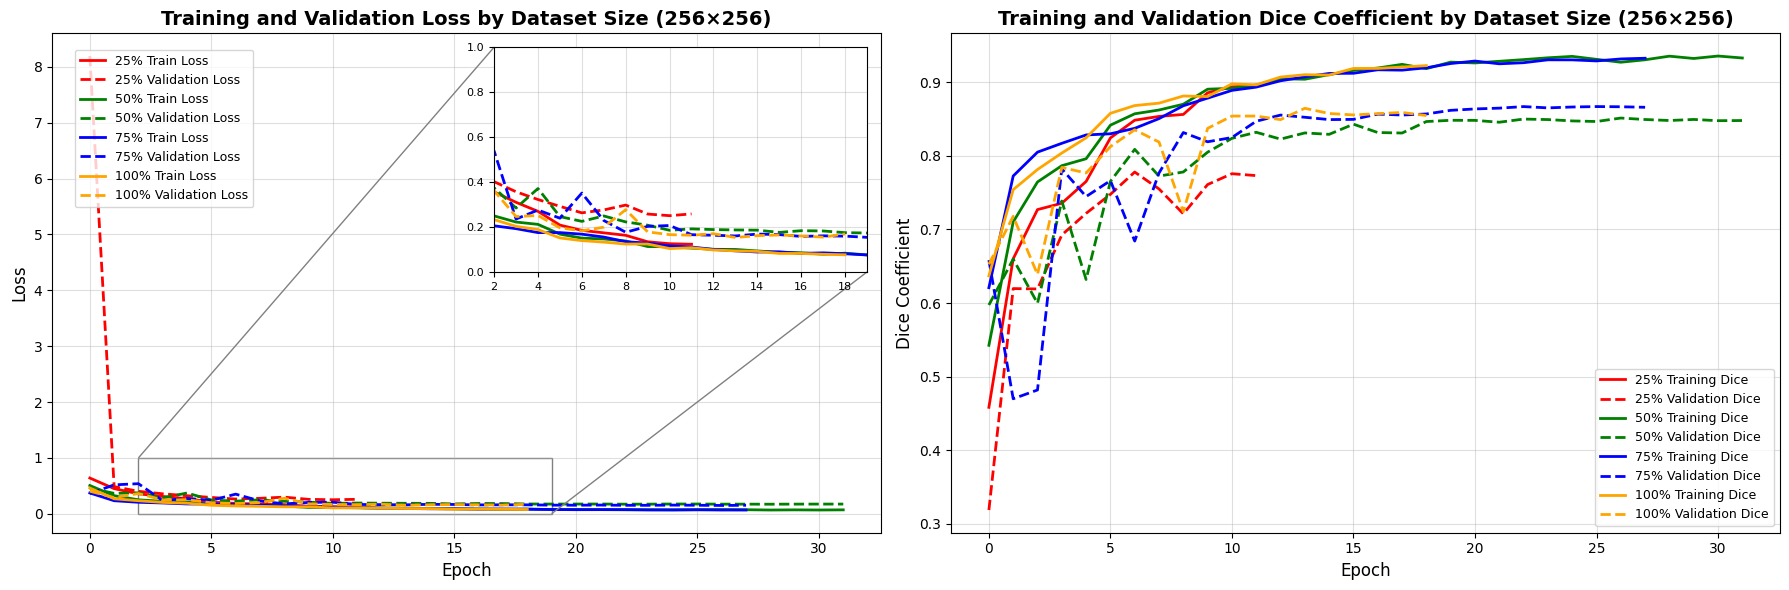

In [ ]:
plt.figure(figsize=(18, 6))

# Left subplot: Loss curves
ax1 = plt.subplot(1, 2, 1)
ax1.plot(history_25['train_loss'], label='25% Train Loss', color='red', linewidth=2)
ax1.plot(history_25['val_loss'], label='25% Validation Loss', color='red', linestyle='--', linewidth=2)
ax1.plot(history_50['train_loss'], label='50% Train Loss', color='green', linewidth=2)
ax1.plot(history_50['val_loss'], label='50% Validation Loss', color='green', linestyle='--', linewidth=2)
ax1.plot(history_75['train_loss'], label='75% Train Loss', color='blue', linewidth=2)
ax1.plot(history_75['val_loss'], label='75% Validation Loss', color='blue', linestyle='--', linewidth=2)
ax1.plot(history_100['train_loss'], label='100% Train Loss', color='orange', linewidth=2)
ax1.plot(history_100['val_loss'], label='100% Validation Loss', color='orange', linestyle='--', linewidth=2)

ax1.set_title('Training and Validation Loss by Dataset Size (256×256)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.grid(True, alpha=0.4)
ax1.tick_params(axis='both', labelsize=10)

# Move legend to the upper-left corner (so it doesn't overlap inset)
ax1.legend(fontsize=9, loc='upper left', bbox_to_anchor=(0.02, 0.98))

# Zoomed-in inset (focus after epoch 2)
axins = inset_axes(ax1, width="45%", height="45%", loc='upper right', borderpad=1)
for color, hist in zip(['red', 'green', 'blue', 'orange'],
                       [history_25, history_50, history_75, history_100]):
    axins.plot(hist['train_loss'], color=color, linewidth=2)
    axins.plot(hist['val_loss'], color=color, linestyle='--', linewidth=2)

axins.set_xlim(2, len(history_100['train_loss']))  # zoom region
axins.set_ylim(0, 1)
axins.grid(True, alpha=0.4)
axins.tick_params(labelsize=8)
mark_inset(ax1, axins, loc1=2, loc2=4, fc="none", ec="0.5")

# Right subplot: Dice coefficient
ax2 = plt.subplot(1, 2, 2)
ax2.plot(history_25['train_dice'], label='25% Training Dice', color='red', linewidth=2)
ax2.plot(history_25['val_dice'], label='25% Validation Dice', color='red', linestyle='--', linewidth=2)
ax2.plot(history_50['train_dice'], label='50% Training Dice', color='green', linewidth=2)
ax2.plot(history_50['val_dice'], label='50% Validation Dice', color='green', linestyle='--', linewidth=2)
ax2.plot(history_75['train_dice'], label='75% Training Dice', color='blue', linewidth=2)
ax2.plot(history_75['val_dice'], label='75% Validation Dice', color='blue', linestyle='--', linewidth=2)
ax2.plot(history_100['train_dice'], label='100% Training Dice', color='orange', linewidth=2)
ax2.plot(history_100['val_dice'], label='100% Validation Dice', color='orange', linestyle='--', linewidth=2)

ax2.set_title('Training and Validation Dice Coefficient by Dataset Size (256×256)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Dice Coefficient', fontsize=12)
ax2.legend(fontsize=9, loc='lower right')
ax2.grid(True, alpha=0.4)
ax2.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()


###Step 13.2 SUMMARY: Impact of Training Dataset Size (256×256)

In [ ]:
# Create a summary comparison of best validation Dice scores
best_dice_25 = max(history_25['val_dice'])
best_dice_50 = max(history_50['val_dice'])
best_dice_75 = max(history_75['val_dice'])
best_dice_100 = max(history_100['val_dice'])

# Create summary table
summary_data = {
    'Training Data Size': ['25%', '50%', '75%', '100%'],
    'Number of Samples': [
        len(train_list_25),
        len(train_list_50),
        len(train_list_75),
        len(train_list_100)
    ],
    'Best Validation Dice': [
        best_dice_25,
        best_dice_50,
        best_dice_75,
        best_dice_100
    ],
    'Epochs Trained': [
        len(history_25['val_dice']),
        len(history_50['val_dice']),
        len(history_75['val_dice']),
        len(history_100['val_dice'])
    ]
}

print("\n" + "="*60)
print("SUMMARY: Impact of Training Dataset Size (256×256)")
print("="*60)
print(f"{'Size':<10} {'Samples':<12} {'Best Val Dice':<18} {'Epochs':<10}")
print("-"*60)
for i in range(4):
    print(f"{summary_data['Training Data Size'][i]:<10} "
          f"{summary_data['Number of Samples'][i]:<12} "
          f"{summary_data['Best Validation Dice'][i]:<18.4f} "
          f"{summary_data['Epochs Trained'][i]:<10}")
print("="*60)

# Save summary to CSV
summary_csv_path = os.path.join(RESULTS_DIR, "dataset_size_summary_256x256.csv")
with open(summary_csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Training Data Size', 'Number of Samples', 'Best Validation Dice', 'Epochs Trained'])
    for i in range(4):
        writer.writerow([
            summary_data['Training Data Size'][i],
            summary_data['Number of Samples'][i],
            summary_data['Best Validation Dice'][i],
            summary_data['Epochs Trained'][i]
        ])
print(f"\nSummary saved to: {summary_csv_path}")



SUMMARY: Impact of Training Dataset Size (256×256)
Size       Samples      Best Val Dice      Epochs    
------------------------------------------------------------
25%        220          0.7778             12        
50%        440          0.8511             32        
75%        660          0.8667             28        
100%       880          0.8644             19        

Summary saved to: /content/drive/MyDrive/00_Colab Notebooks/5_DeepLearning/Exam/results/dataset_size_summary_256x256.csv


### Step 13.3 Best Validation Dice Score by Training dataset size

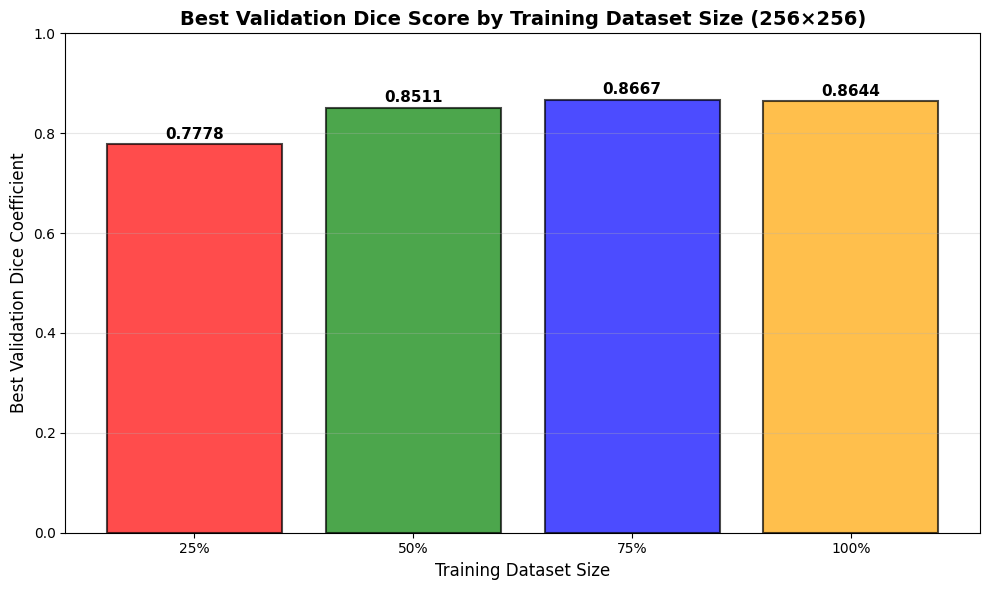

In [ ]:
# Visualize best validation Dice scores as a bar chart
plt.figure(figsize=(10, 6))
sizes = ['25%', '50%', '75%', '100%']
best_dice_scores = [best_dice_25, best_dice_50, best_dice_75, best_dice_100]
colors = ['red', 'green', 'blue', 'orange']

bars = plt.bar(sizes, best_dice_scores, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for i, (bar, score) in enumerate(zip(bars, best_dice_scores)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.title('Best Validation Dice Score by Training Dataset Size (256×256)', fontsize=14, fontweight='bold')
plt.xlabel('Training Dataset Size', fontsize=12)
plt.ylabel('Best Validation Dice Coefficient', fontsize=12)
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "dataset_size_best_dice_comparison_256x256.png"), dpi=150, bbox_inches='tight')
plt.show()

### Step 13.4 Predicted Masks Comparison by Training Dataset Size

Visual comparison of segmentation predictions from models trained with different amounts of training data (all at 256×256 resolution).


Visualizing predictions for 3 sample(s) from validation set...


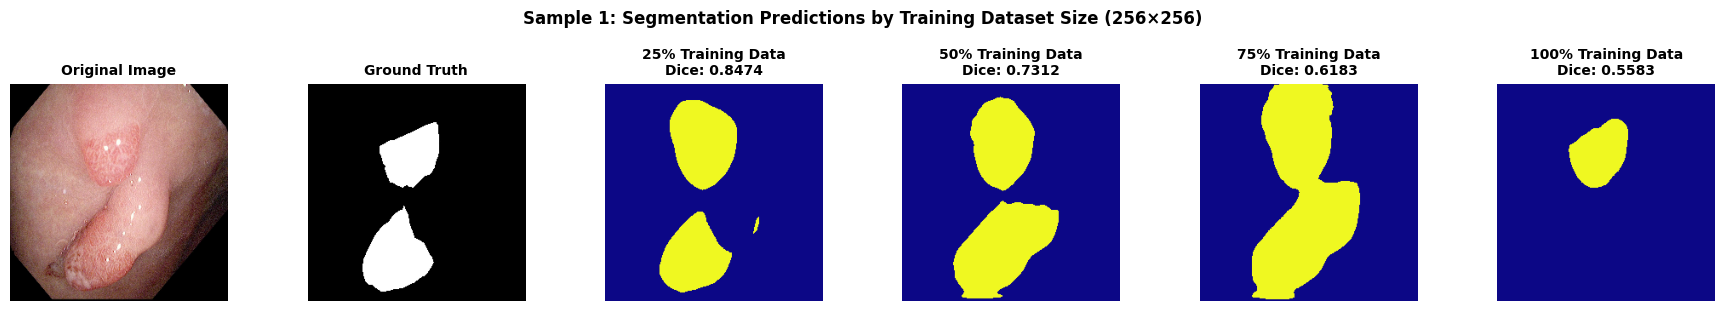

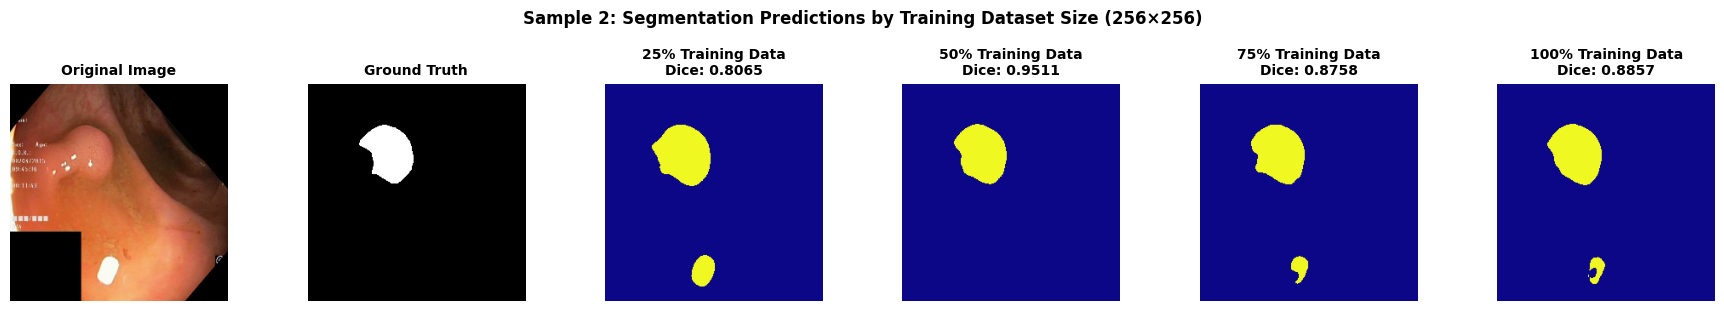

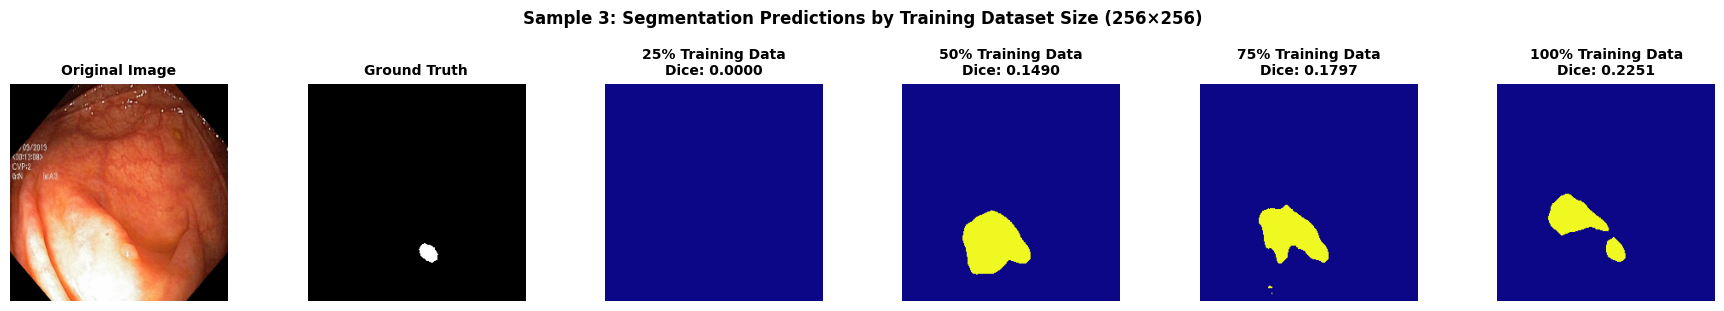

In [ ]:
# Make sure all models are in eval mode
model_unet_25.eval()
model_unet_50.eval()
model_unet_75.eval()
model_unet_100.eval()

# Get one batch from validation dataloader
imgs, masks = next(iter(val_dataloader_256_size))

# Pick 3 random indices from the batch
indices = random.sample(range(imgs.size(0)), 3)

print(f"Visualizing predictions for {len(indices)} sample(s) from validation set...")

for idx, i in enumerate(indices):
    img = imgs[i].to(DEVICE)      # (3, H, W)
    mask = masks[i].to(DEVICE)    # (H, W)

    with torch.no_grad():
        # 25% training data predictions
        pred_unet_25 = model_unet_25(img.unsqueeze(0))
        pred_unet_25 = torch.sigmoid(pred_unet_25)[0, 0]
        pred_unet_25 = (pred_unet_25 > 0.5).float()

        # 50% training data predictions
        pred_unet_50 = model_unet_50(img.unsqueeze(0))
        pred_unet_50 = torch.sigmoid(pred_unet_50)[0, 0]
        pred_unet_50 = (pred_unet_50 > 0.5).float()

        # 75% training data predictions
        pred_unet_75 = model_unet_75(img.unsqueeze(0))
        pred_unet_75 = torch.sigmoid(pred_unet_75)[0, 0]
        pred_unet_75 = (pred_unet_75 > 0.5).float()

        # 100% training data predictions
        pred_unet_100 = model_unet_100(img.unsqueeze(0))
        pred_unet_100 = torch.sigmoid(pred_unet_100)[0, 0]
        pred_unet_100 = (pred_unet_100 > 0.5).float()

    # Convert to numpy for plotting
    img_np = img.permute(1, 2, 0).cpu().numpy()
    mask_np = mask.squeeze().cpu().numpy()
    pred_unet_25_np = pred_unet_25.cpu().numpy()
    pred_unet_50_np = pred_unet_50.cpu().numpy()
    pred_unet_75_np = pred_unet_75.cpu().numpy()
    pred_unet_100_np = pred_unet_100.cpu().numpy()

    # Calculate Dice scores for each prediction (for display)
    def calc_dice_single(pred_np, mask_np):
        pred_flat = pred_np.flatten()
        mask_flat = (mask_np / 255.0).flatten()
        intersection = (pred_flat * mask_flat).sum()
        dice = (2. * intersection + 1e-6) / (pred_flat.sum() + mask_flat.sum() + 1e-6)
        return dice

    dice_25 = calc_dice_single(pred_unet_25_np, mask_np)
    dice_50 = calc_dice_single(pred_unet_50_np, mask_np)
    dice_75 = calc_dice_single(pred_unet_75_np, mask_np)
    dice_100 = calc_dice_single(pred_unet_100_np, mask_np)

    # Plot 1x6: Image | Ground Truth | 25% | 50% | 75% | 100%
    fig, axes = plt.subplots(1, 6, figsize=(18, 3))

    axes[0].imshow(img_np)
    axes[0].set_title("Original Image", fontsize=10, fontweight='bold')
    axes[0].axis("off")

    axes[1].imshow(mask_np, cmap="gray")
    axes[1].set_title("Ground Truth", fontsize=10, fontweight='bold')
    axes[1].axis("off")

    axes[2].imshow(pred_unet_25_np, cmap="plasma")
    axes[2].set_title(f"25% Training Data\nDice: {dice_25:.4f}", fontsize=10, fontweight='bold')
    axes[2].axis("off")

    axes[3].imshow(pred_unet_50_np, cmap="plasma")
    axes[3].set_title(f"50% Training Data\nDice: {dice_50:.4f}", fontsize=10, fontweight='bold')
    axes[3].axis("off")

    axes[4].imshow(pred_unet_75_np, cmap="plasma")
    axes[4].set_title(f"75% Training Data\nDice: {dice_75:.4f}", fontsize=10, fontweight='bold')
    axes[4].axis("off")

    axes[5].imshow(pred_unet_100_np, cmap="plasma")
    axes[5].set_title(f"100% Training Data\nDice: {dice_100:.4f}", fontsize=10, fontweight='bold')
    axes[5].axis("off")

    plt.suptitle(f'Sample {idx+1}: Segmentation Predictions by Training Dataset Size (256×256)',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()

    plt.savefig(os.path.join(RESULTS_DIR, f"dataset_size_prediction_comparison_sample_{idx+1}.png"),
                dpi=150, bbox_inches='tight')
    plt.show()